# Module 07: TensorFlow & Keras for Deep Learning
## Notebook 01: Tensors, Computational Graphs, and Automatic Differentiation

TensorFlow is an end-to-end open-source machine learning and deep learning framework developed by the Google Brain team. At its foundation lies a high-performance numerical engine for multidimensional array computations (Tensors) with automatic differentiation (Autodiff) and hardware acceleration across CPUs, GPUs, and TPUs.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Understand the core properties of **Tensors**: rank, shape, data types, and device placement.
2. Create immutable constants (`tf.constant`) and mutable model parameters (`tf.Variable`).
3. Execute tensor algebra, matrix multiplications (`tf.matmul`), broadcasting, and reshaping.
4. Seamlessly bridge **NumPy arrays** and **TensorFlow tensors** with zero-copy memory semantics.
5. Compute analytical gradients using **`tf.GradientTape`** for single-variable and multi-variable functions.
6. **Advanced:** Construct a **Custom Gradient-Descent Optimization Loop from Scratch** without high-level Keras APIs.
7. **Advanced:** Accelerate Python code into optimized computation graphs using **`@tf.function`** and AutoGraph.

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  #Suppress warning messages

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")
print(f"Eager Execution Enabled: {tf.executing_eagerly()}")
print(f"Available Devices: {[d.name for d in tf.config.list_physical_devices()]}")

TensorFlow Version: 2.21.0
Eager Execution Enabled: True
Available Devices: ['/physical_device:CPU:0']


### 1. Tensor Fundamentals: Rank, Shape & Types
A **Tensor** is a generalization of vectors and matrices to potentially higher dimensions:
- **Rank 0 (Scalar):** A single number (e.g. `tf.constant(42)`).
- **Rank 1 (Vector):** 1D array of values (e.g. feature values for a single sample).
- **Rank 2 (Matrix):** 2D array (e.g. tabular batch of shape `[batch_size, num_features]`).
- **Rank 3:** 3D array (e.g. time-series / NLP sequences `[batch_size, sequence_length, embedding_dim]`).
- **Rank 4:** 4D array (e.g. image batches `[batch_size, height, width, channels]`).

Tensors are **immutable** (`tf.constant`). To represent model weights that update during training, TensorFlow provides **`tf.Variable`**.

In [3]:
# 1. Immutable Tensors (tf.constant)
scalar = tf.constant(3.14159, dtype=tf.float32)
vector = tf.constant([1.0, 2.0, 3.0, 4.0])
matrix = tf.constant([[1.0, 2.0], [3.0, 4.0]], dtype=tf.float32)
tensor_4d = tf.random.normal(shape=[8, 28, 28, 1]) # Batch of 8 grayscale images

print(f"Scalar: shape={scalar.shape}, rank={scalar.ndim}, dtype={scalar.dtype}")
print(f"Matrix: shape={matrix.shape}, rank={matrix.ndim}")
print(f"4D Image Batch: shape={tensor_4d.shape}, rank={tensor_4d.ndim}")

# 2. Mutable Model Weights (tf.Variable)
weights = tf.Variable(tf.random.truncated_normal(shape=[4, 2], stddev=0.1), name="layer_weights")
print(f"\nInitial Variable Weights:\n{weights.numpy()}")

# In-place parameter mutation via assign_add and assign_sub
weights.assign_add(tf.ones([4, 2]) * 0.05)
print(f"\nMutated Weights (+0.05):\n{weights.numpy()}")

Scalar: shape=(), rank=0, dtype=<dtype: 'float32'>
Matrix: shape=(2, 2), rank=2
4D Image Batch: shape=(8, 28, 28, 1), rank=4

Initial Variable Weights:
[[-0.11770423  0.1089645 ]
 [-0.00165333  0.17627047]
 [-0.10382126 -0.00502877]
 [-0.06507694  0.1436004 ]]

Mutated Weights (+0.05):
[[-0.06770423  0.1589645 ]
 [ 0.04834668  0.22627047]
 [-0.05382125  0.04497124]
 [-0.01507694  0.1936004 ]]


### 2. Tensor Math, Matrix Multiplication & Broadcasting
TensorFlow supports standard element-wise arithmetic and linear algebra:
- **Element-wise arithmetic:** `+`, `-`, `*`, `/`, `tf.exp()`, `tf.math.log()`, `tf.math.sqrt()`.
- **Matrix Multiplication:** `tf.matmul(A, B)` or the `@` operator.
  - Dimension requirement: inner dimensions must match $(M, K) \times (K, N) \to (M, N)$.
- **Broadcasting:** Automatically stretches compatible singleton dimensions across axes without duplicating memory.
- **Reshaping & Permutations:** `tf.reshape()`, `tf.transpose()`, `tf.squeeze()`, `tf.expand_dims()`.

In [4]:
# 1. Matrix Multiplication
A = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]) # Shape (2, 3)
B = tf.constant([[7.0, 8.0], [9.0, 10.0], [11.0, 12.0]]) # Shape (3, 2)
C = tf.matmul(A, B) # Or: A @ B -> Shape (2, 2)
print(f"Matrix Product (2, 3) @ (3, 2) = {C.shape}:\n{C.numpy()}")

# 2. Broadcasting demonstration: Adding a bias vector (1, 2) to a batch (4, 2)
batch_activations = tf.ones([4, 2], dtype=tf.float32) * 5.0
bias_vector = tf.constant([0.5, -0.5], dtype=tf.float32) # Shape (2,) broadcast to (4, 2)
biased_output = batch_activations + bias_vector
print(f"\nBroadcasting result:\n{biased_output.numpy()}")

# 3. Reshaping and Dimension manipulation
flat = tf.range(12, dtype=tf.float32)
reshaped_2d = tf.reshape(flat, [3, 4])
expanded_3d = tf.expand_dims(reshaped_2d, axis=-1) # Shape (3, 4, 1)
squeezed_2d = tf.squeeze(expanded_3d, axis=-1) # Back to (3, 4)
print(f"\nReshaped: {reshaped_2d.shape} -> Expanded: {expanded_3d.shape} -> Squeezed: {squeezed_2d.shape}")

Matrix Product (2, 3) @ (3, 2) = (2, 2):
[[ 58.  64.]
 [139. 154.]]

Broadcasting result:
[[5.5 4.5]
 [5.5 4.5]
 [5.5 4.5]
 [5.5 4.5]]

Reshaped: (3, 4) -> Expanded: (3, 4, 1) -> Squeezed: (3, 4)


### 3. Automatic Differentiation with `tf.GradientTape`
Deep learning models optimize loss functions via gradient descent. Computing analytical derivatives manually for millions of parameters is intractable.
TensorFlow uses **Reverse-Mode Automatic Differentiation (`tf.GradientTape`)**:
- All operations performed inside a `with tf.GradientTape() as tape:` block on watched tensors or `tf.Variable`s are recorded on a computational tape.
- Calling `tape.gradient(target, sources)` traces backwards through the recorded graph to compute exact analytical gradients via the calculus chain rule:
  $$\frac{\partial y}{\partial x_i}$$
- **Persistent Tape (`persistent=True`):** Allows multiple gradient evaluations from the same recorded forward pass.

In [5]:
# 1. Single-variable gradient: y = x^3 - 4x^2 + 7 at x = 3.0
# Analytical derivative: dy/dx = 3x^2 - 8x. At x = 3: 3(9) - 8(3) = 27 - 24 = 3.0
x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x**3 - 4.0 * x**2 + 7.0

grad_y_x = tape.gradient(y, x)
print(f"Target y = x^3 - 4x^2 + 7 at x=3.0 -> y = {y.numpy():.2f}")
print(f"Computed dy/dx via GradientTape: {grad_y_x.numpy():.2f} (Expected: 3.00)")

# 2. Multi-variable gradients for a linear neuron: z = w1*x1 + w2*x2 + b
w = tf.Variable([2.0, -1.5], dtype=tf.float32)
b = tf.Variable(0.5, dtype=tf.float32)
x_in = tf.constant([1.0, 4.0], dtype=tf.float32)

with tf.GradientTape() as tape:
    z = tf.reduce_sum(w * x_in) + b
    loss = tf.square(z - 10.0) # Quadratic loss

# Compute gradients with respect to w and b simultaneously
[grad_w, grad_b] = tape.gradient(loss, [w, b])
print(f"\nMulti-variable loss: {loss.numpy():.4f}")
print(f"dL/dw: {grad_w.numpy()}, dL/db: {grad_b.numpy():.4f}")

# 3. Second-Order Derivatives (Hessian diagonal) via Nested Tapes
x_val = tf.Variable(2.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        # f(x) = x^4 -> f'(x) = 4x^3 -> f''(x) = 12x^2. At x=2: 12(4) = 48.0
        f = x_val**4
    first_deriv = inner_tape.gradient(f, x_val)
second_deriv = outer_tape.gradient(first_deriv, x_val)

print(f"\nNested Tape Second Derivative of x^4 at x=2.0: {second_deriv.numpy():.1f} (Expected: 48.0)")

Target y = x^3 - 4x^2 + 7 at x=3.0 -> y = -2.00
Computed dy/dx via GradientTape: 3.00 (Expected: 3.00)

Multi-variable loss: 182.2500
dL/dw: [ -27. -108.], dL/db: -27.0000

Nested Tape Second Derivative of x^4 at x=2.0: 48.0 (Expected: 48.0)


### 4. Complex Application 1: Custom Gradient-Descent Optimization Loop from Scratch
In production ML research, novel architectures require custom training dynamics beyond standard `model.fit()`.
Below, we implement a pure TensorFlow training loop from scratch to fit a multi-variable regression model without Keras:
- Ground truth function: $y = 3.5 x_1 - 2.0 x_2 + 1.5 + \epsilon$
- Model formulation: $\hat{y} = X W + b$
- Loss formulation: $\mathcal{L} = \frac{1}{N} \sum (\hat{y} - y)^2$
- Optimization update rule:
  $$W \leftarrow W - \eta \frac{\partial \mathcal{L}}{\partial W}, \quad b \leftarrow b - \eta \frac{\partial \mathcal{L}}{\partial b}$$

--- TRAINING CONVERGENCE SUMMARY ---
Fitted W: [3.497, -2.013] (True: [3.500, -2.000])
Fitted b: 1.507 (True: 1.500)
Final Mean Squared Error: 0.2384


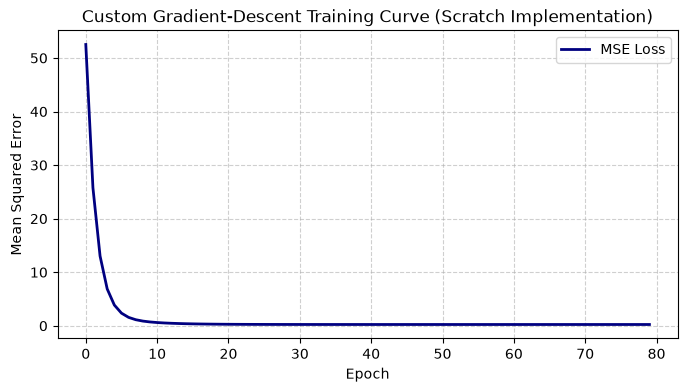

In [6]:
# 1. Synthesize multi-variable regression dataset
np.random.seed(42)
N = 1000
X_np = np.random.uniform(-3.0, 3.0, size=(N, 2)).astype(np.float32)
true_W = np.array([[3.5], [-2.0]], dtype=np.float32)
true_b = 1.5
noise = np.random.normal(0, 0.5, size=(N, 1)).astype(np.float32)
y_np = X_np @ true_W + true_b + noise

X_tf = tf.constant(X_np)
y_tf = tf.constant(y_np)

# 2. Initialize trainable parameters
W_model = tf.Variable(tf.zeros([2, 1], dtype=tf.float32))
b_model = tf.Variable(tf.zeros([1], dtype=tf.float32))

# 3. Training Loop from scratch
learning_rate = 0.05
epochs = 80
loss_history = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = tf.matmul(X_tf, W_model) + b_model
        loss = tf.reduce_mean(tf.square(y_pred - y_tf))

    # Compute exact analytical gradients
    grad_W, grad_b = tape.gradient(loss, [W_model, b_model])

    # Apply gradient descent parameter updates in-place
    W_model.assign_sub(learning_rate * grad_W)
    b_model.assign_sub(learning_rate * grad_b)

    loss_history.append(loss.numpy())

print("--- TRAINING CONVERGENCE SUMMARY ---")
print(f"Fitted W: [{W_model[0, 0].numpy():.3f}, {W_model[1, 0].numpy():.3f}] (True: [3.500, -2.000])")
print(f"Fitted b: {b_model[0].numpy():.3f} (True: 1.500)")
print(f"Final Mean Squared Error: {loss_history[-1]:.4f}")

# Plot optimization loss trajectory
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color="navy", lw=2, label="MSE Loss")
plt.title("Custom Gradient-Descent Training Curve (Scratch Implementation)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

### 5. Complex Application 2: High-Performance Graph Compilation with `@tf.function`
TensorFlow defaults to **Eager Execution** (imperative Python line-by-line execution, great for debugging).
However, in production deployment, eager execution suffers from Python interpreter overhead.
- **`@tf.function`:** Compiles standard Python functions into optimized, non-Python computation graphs using AutoGraph.
- Executes independent operations concurrently, prunes unused subgraphs, and fuses kernels for extreme speedups.

In [7]:
import time

# Define non-decorated eager function
def eager_step(x, w, b):
    return tf.nn.relu(tf.matmul(x, w) + b)

# Define graph-compiled function
@tf.function
def graph_step(x, w, b):
    return tf.nn.relu(tf.matmul(x, w) + b)

# Create large benchmark matrices
dim = 2000
x_bench = tf.random.normal([dim, dim])
w_bench = tf.random.normal([dim, dim])
b_bench = tf.random.normal([dim])

# Warmup graph tracing
_ = graph_step(x_bench, w_bench, b_bench)

# Benchmark Eager Mode (10 iterations)
t0 = time.time()
for _ in range(10):
    _ = eager_step(x_bench, w_bench, b_bench)
eager_duration = (time.time() - t0) * 1000

# Benchmark Graph Mode (10 iterations)
t0 = time.time()
for _ in range(10):
    _ = graph_step(x_bench, w_bench, b_bench)
graph_duration = (time.time() - t0) * 1000

print(f"Eager Execution (10 steps): {eager_duration:.2f} ms")
print(f"Graph Execution with @tf.function (10 steps): {graph_duration:.2f} ms")
print(f"Speedup Factor: {eager_duration / max(graph_duration, 1e-5):.2f}x")

Eager Execution (10 steps): 1229.15 ms
Graph Execution with @tf.function (10 steps): 1209.77 ms
Speedup Factor: 1.02x
